# (노트) 이미지자료분석 실전

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [데이터과학]

### imports

In [236]:
import tensorflow as tf

In [237]:
import numpy as np

In [238]:
import matplotlib.pyplot as plt

### data

In [239]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [240]:
X = x_train.reshape(-1,28,28,1)
y = tf.keras.utils.to_categorical(y_train)
XX = x_test.reshape(-1,28,28,1)
yy = tf.keras.utils.to_categorical(y_test)

### DNN network

In [241]:
net = tf.keras.Sequential()
net.add(tf.keras.layers.Flatten()) 
net.add(tf.keras.layers.Dense(50,activation='relu')) 
net.add(tf.keras.layers.Dense(10,activation='softmax')) 

In [242]:
net.compile(optimizer='adam',loss=tf.losses.categorical_crossentropy,metrics='accuracy')

In [243]:
cbck = tf.keras.callbacks.TensorBoard(write_images=True)

In [244]:
net.fit(X,y,epochs=200,batch_size=200,validation_split=0.2,callbacks=cbck)

Epoch 1/200
240/240 [==============================] - 0s 1ms/step - loss: 10.2869 - accuracy: 0.6221 - val_loss: 1.4498 - val_accuracy: 0.6644
Epoch 2/200
240/240 [==============================] - 0s 822us/step - loss: 1.1230 - accuracy: 0.6597 - val_loss: 1.0340 - val_accuracy: 0.6664
Epoch 3/200
240/240 [==============================] - 0s 868us/step - loss: 0.8942 - accuracy: 0.6862 - val_loss: 0.8930 - val_accuracy: 0.6913
Epoch 4/200
240/240 [==============================] - 0s 816us/step - loss: 0.7938 - accuracy: 0.7019 - val_loss: 0.8082 - val_accuracy: 0.6996
Epoch 5/200
240/240 [==============================] - 0s 833us/step - loss: 0.7338 - accuracy: 0.7126 - val_loss: 0.7574 - val_accuracy: 0.7246
Epoch 6/200
240/240 [==============================] - 0s 826us/step - loss: 0.6929 - accuracy: 0.7252 - val_loss: 0.7376 - val_accuracy: 0.7278
Epoch 7/200
240/240 [==============================] - 0s 867us/step - loss: 0.6578 - accuracy: 0.7352 - val_loss: 0.7240 - val_acc

### 텐서보드 기본시각화 

`-` 파이썬 3.10의 경우 아래의 수정이 필요

`?/python3.10/site-packages/tensorboard/_vendor/html5lib/_trie/_base.py` 을 열고
```python
from collections import Mapping ### 수정전
from collections.abc import Mapping ### 수정후 
```
와 같이 수정한다. 

- 에러나는이유? 파이썬 3.10부터는 `from collections.abc import Mapping`이 실행되고 `from collections import Mapping`은 실행안된다. 

`-` 텐서보드 여는 방법1

In [245]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [246]:
%tensorboard --logdir logs --host 0.0.0.0

Reusing TensorBoard on port 6006 (pid 150299), started 3:01:14 ago. (Use '!kill 150299' to kill it.)

- 노트북에서 바로보인다..

`-` 텐서보드 여는 방법2 

In [18]:
!tensorboard --logdir logs --host 0.0.0.0

2022-05-21 19:10:19.989437: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-21 19:10:20.011557: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-21 19:10:20.011701: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

TensorBoard 2.6.0 at http://0.0.0.0:6007/ (Press CTRL+C to quit)
^C


- 이제 `210.117.173.184:6007` 로 가면된다. 

### 조기종료 

`-` 텐서보드를 살펴보니 

### 하이퍼파라메터 선택 

### 중간층시각화 

### 하이퍼파라메터 선택 (옵티마이저

### 학습률 스케쥴러

### 하이퍼파라메터 선택 1

In [248]:
from tensorboard.plugins.hparams import api as hp

In [249]:
HP_NUM_UNITS = hp.HParam('num_units', hp.Discrete([16, 32]))
HP_DROPOUT = hp.HParam('dropout', hp.RealInterval(0.1, 0.2))
HP_OPTIMIZER = hp.HParam('optimizer', hp.Discrete(['adam', 'sgd']))

METRIC_ACCURACY = 'accuracy'

with tf.summary.create_file_writer('logs/hparam_tuning').as_default():
    hp.hparams_config(
        hparams=[HP_NUM_UNITS, HP_DROPOUT, HP_OPTIMIZER],
        metrics=[hp.Metric(METRIC_ACCURACY, display_name='Accuracy')],
    )

In [250]:
def train_test_model(hparams):
  model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(hparams[HP_NUM_UNITS], activation=tf.nn.relu),
    tf.keras.layers.Dropout(hparams[HP_DROPOUT]),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax),
  ])
  model.compile(
      optimizer=hparams[HP_OPTIMIZER],
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy'],
  )

  model.fit(x_train, y_train, epochs=1) # Run with 1 epoch to speed things up for demo purposes
  _, accuracy = model.evaluate(x_test, y_test)
  return accuracy


In [251]:
def run(run_dir, hparams):
  with tf.summary.create_file_writer(run_dir).as_default():
    hp.hparams(hparams)  # record the values used in this trial
    accuracy = train_test_model(hparams)
    tf.summary.scalar(METRIC_ACCURACY, accuracy, step=1)

In [253]:
session_num = 0

for num_units in HP_NUM_UNITS.domain.values:
  for dropout_rate in (HP_DROPOUT.domain.min_value, HP_DROPOUT.domain.max_value):
    for optimizer in HP_OPTIMIZER.domain.values:
      hparams = {
          HP_NUM_UNITS: num_units,
          HP_DROPOUT: dropout_rate,
          HP_OPTIMIZER: optimizer,
      }
      run_name = "run-%d" % session_num
      print('--- Starting trial: %s' % run_name)
      print({h.name: hparams[h] for h in hparams})
      run('logs/hparam_tuning/' + run_name, hparams)
      session_num += 1

--- Starting trial: run-0
{'num_units': 16, 'dropout': 0.1, 'optimizer': 'adam'}
313/313 [==============================] - 0s 571us/step - loss: 1.6311 - accuracy: 0.3649
--- Starting trial: run-1
{'num_units': 16, 'dropout': 0.1, 'optimizer': 'sgd'}
313/313 [==============================] - 0s 547us/step - loss: 2.3026 - accuracy: 0.1000
--- Starting trial: run-2
{'num_units': 16, 'dropout': 0.2, 'optimizer': 'adam'}
313/313 [==============================] - 0s 562us/step - loss: 2.0389 - accuracy: 0.1986
--- Starting trial: run-3
{'num_units': 16, 'dropout': 0.2, 'optimizer': 'sgd'}
313/313 [==============================] - 0s 631us/step - loss: 2.3026 - accuracy: 0.1000
--- Starting trial: run-4
{'num_units': 32, 'dropout': 0.1, 'optimizer': 'adam'}
313/313 [==============================] - 0s 533us/step - loss: 1.4264 - accuracy: 0.4801
--- Starting trial: run-5
{'num_units': 32, 'dropout': 0.1, 'optimizer': 'sgd'}
313/313 [==============================] - 0s 560us/step - los

In [255]:
%tensorboard --logdir logs/hparam_tuning --host 0.0.0.0

### 이미지자료 시각화 

In [120]:
!rm -rf logs

In [121]:
#from datetime import datetime
logdir = "logs/STEP1/"
file_writer = tf.summary.create_file_writer(logdir)

In [124]:
with file_writer.as_default():
    tf.summary.image("STEP1: 입력샘플들", img, max_outputs=9, step=0) # step의 의미?

In [134]:
%tensorboard --logdir logs --host 0.0.0.0

Reusing TensorBoard on port 6006 (pid 150299), started 0:08:24 ago. (Use '!kill 150299' to kill it.)

### 임의의 matplotlib 결과 시각화

In [232]:
# Clear out prior logging data.
!rm -rf logs/plots

logdir = "logs/STEP2/"
file_writer = tf.summary.create_file_writer(logdir)

def plot_to_image(figure):
    """Converts the matplotlib plot specified by 'figure' to a PNG image and
    returns it. The supplied figure is closed and inaccessible after this call."""
    # Save the plot to a PNG in memory.
    buf = io.BytesIO()
    figure.savefig(buf, format='png')
    # Closing the figure prevents it from being displayed directly inside
    # the notebook.
    plt.close(figure)
    buf.seek(0)
    # Convert PNG buffer to TF image
    image = tf.image.decode_png(buf.getvalue(), channels=4)
    # Add the batch dimension
    image = tf.expand_dims(image, 0)
    return image


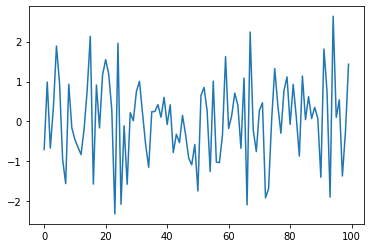

In [233]:
fig = plt.figure()
plt.plot(np.random.randn(100))

In [234]:
with file_writer.as_default():
    tf.summary.image("Training data", plot_to_image(fig), step=0)

In [235]:
%tensorboard --logdir logs --host 0.0.0.0

Reusing TensorBoard on port 6006 (pid 150299), started 2:54:13 ago. (Use '!kill 150299' to kill it.)